<img src="https://lund-observatory-teaching.github.io/lundpython/imgs/front_3.jpeg" width="1400">

To download all lecture files and see the schedule, please visit:

[lund-observatory-teaching.github.io/lundpython/](https://lund-observatory-teaching.github.io/lundpython/)

Each lecture contains (as notebooks)
- Manual 
- Exercises
- Presentation

---

# Plotting in Python
<br>
<img src="https://lund-observatory-teaching.github.io/lundpython/imgs/matplotlib.png" width="600">

> [Matplotlib](https://matplotlib.org) is a comprehensive library for creating static, animated, and interactive visualizations in Python.

<br>
<br>

Most of what we do today will revolve around the sub-package `pyplot`. Typically we do:

In [2]:
import matplotlib.pyplot as plt

`matplotlib` is designed to be similar to MATLAB, so if you have ever used MATLAB you will feel familiar.

`matplotlib` will let you graph your data on a `Figure`. That `Figure` contains one or more `Axes`. To explain this, let's consider the following illustration:

<img src="https://lund-observatory-teaching.github.io/lundpython/imgs/anatomy.png" width="900" align="left" style="margin: 0pt 0pt 0pt 250pt;"/>



<img src="https://lund-observatory-teaching.github.io/lundpython/imgs/anatomy.png" width="900" align="right" style="margin: 0pt 0pt 0pt 0pt;"/>

#### <span style="color:red">Figure</span>
The entire plotted thing.
Contains all child  <span style="color:magenta">Axes</span>.
Think of it as a paper you will draw on.

#### <span style="color:magenta">Axes</span>
This is the plot itself.
You might have 2 <span style="color:magenta">Axes</span> next to each other in a single figure.
Contains 2 <span style="color:green">Axis</span> objects, 3 for 3D plots.

#### <span style="color:green">Axis</span>
Sets the graph limit. Takes care of ticks.

#### <span style="color:blue">Artist</span>
Everything *on* the figure is typically an artist (including the <span style="color:red">Figure</span>, <span style="color:magenta">Axes</span>, and <span style="color:green">Axis</span> objects)

`matplotlib` allows plots to be made using [two different interfaces](https://matplotlib.org/stable/tutorials/introductory/usage.html?highlight=interface#the-object-oriented-interface-and-the-pyplot-interface).

### Object-oriented interface

First, we create a **Figure** (the whole figure) and an **Axes** (the plotting area). We then add the data, labels, title, and legend to the `Axes`.

In [4]:
import numpy as np
x = np.linspace(-5, 5, 100)

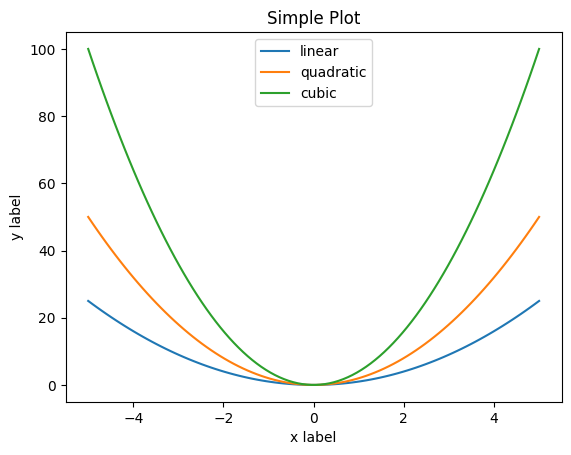

In [3]:
fig, ax = plt.subplots()  # Create a figure and an axes.
ax.plot(x, x**2, label="linear")  # Plot some data on the axes.
ax.plot(x, 2 * x**2, label="quadratic")  # Plot more data on the axes...
ax.plot(x, 4 * x**2, label="cubic")  # ... and some more.
ax.set_xlabel("x label")  # Add a label to the x-axis.
ax.set_ylabel("y label")  # Add a label to the y-axis.
ax.set_title("Simple Plot")  # Add a title.
ax.legend()  # Add a legend.
plt.show()

### Pyplot interface

Here `pyplot` manages the `Figure` and `Axes` for us.

We work directly with `plt` to add the data, labels, title, and legend.

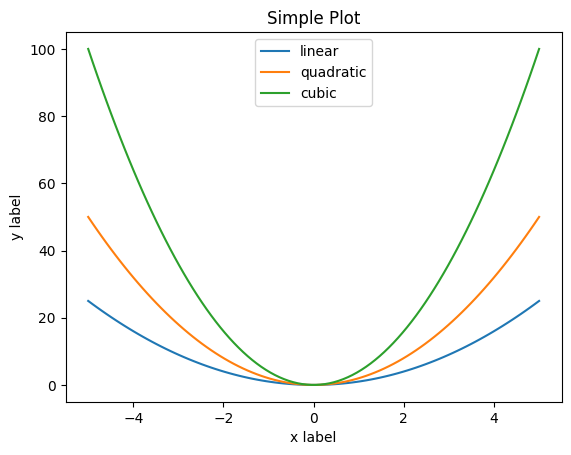

In [4]:
plt.figure()
plt.plot(x, x**2, label="linear")
plt.plot(x, 2 * x**2, label="quadratic")
plt.plot(x, 4 * x**2, label="cubic")
plt.xlabel("x label")
plt.ylabel("y label")
plt.title("Simple Plot")
plt.legend()
plt.show()

These plots are a little hard to read. We would like to make some changes to our style. 

In [5]:
plt.style.use(
    "https://lund-observatory-teaching.github.io/lundpython/3-plotting/presentation.mplstyle",
)

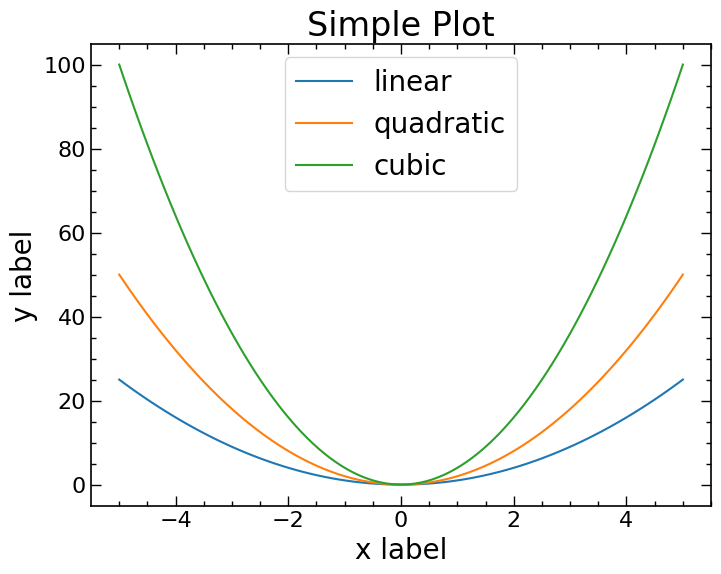

In [6]:
plt.figure()
plt.plot(x, x**2, label="linear")
plt.plot(x, 2 * x**2, label="quadratic")
plt.plot(x, 4 * x**2, label="cubic")
plt.xlabel("x label")
plt.ylabel("y label")
plt.title("Simple Plot")
plt.legend()
plt.show()

Much larger fonts, larger title, larger axis labels, larger tick labels, larger legend, minor ticks are visible, ticks on the top and right as well

### Types of plots

Generate some data to plot:

In [5]:
from numpy.random import default_rng

rng = default_rng()

x1 = rng.standard_normal(size=100)
x2 = np.linspace(0, 5, 100)
y2 = x2**2 - x + rng.standard_normal(size=x2.size)

data3 = np.empty((100_000, 2))
filled_index = 0
for mean, cov, size in zip(
    ([-3, 0], [-1, 2], [-3, 2]),
    ([[0.5, 0], [0, 0.5]], [[1, 0], [0, 0.3]], [[0.7, 0], [0, 0.5]]),
    ([40_000, 20_000, 40_000]),
):
    data3[filled_index : filled_index + size] = rng.multivariate_normal(
        mean=mean,
        cov=cov,
        size=size,
    )
    filled_index += size
x3, y3 = data3.T

In [19]:
def plots():
    f, ax = plt.subplots(3, 5, figsize=(18, 12))
    ax[0, 2].set_title("1D")
    ax[1, 2].set_title("2D")
    ax[2, 2].set_title("2D density")
    ax[0, 2].hist(x1)
    ax[0, 2].set_xlabel("Histogram")
    ax[1, 1].scatter(x2, y2)
    ax[1, 1].set_xlabel("Scatter")
    ax[1, 2].plot(x2, y2)
    ax[1, 2].set_xlabel("Line")
    ax[1, 3].plot(x2, y2, marker=".")
    ax[1, 3].set_xlabel("Mixed")
    counts, x3_edges, y3_edges = np.histogram2d(x3, y3, bins=20)
    ax[2, 0].scatter(x3, y3, s=2, alpha=0.01)
    ax[2, 0].set_xlabel("Scatter")
    ax[2, 1].hist2d(x3, y3, bins=20)
    ax[2, 1].set_xlabel("Histogram")
    ax[2, 2].hexbin(x3, y3, gridsize=20)
    ax[2, 2].set(xlim=(x3.min(), x3.max()), ylim=(y3.min(), y3.max()))
    ax[2, 2].set_xlabel("Hexbin")
    ax[2, 3].contour(
        (x3_edges[1:] + x3_edges[:-1]) / 2,
        (y3_edges[1:] + y3_edges[:-1]) / 2,
        counts.T,
    )
    ax[2, 3].set_xlabel("Contour")
    ax[2, 4].contourf(
        (x3_edges[1:] + x3_edges[:-1]) / 2,
        (y3_edges[1:] + y3_edges[:-1]) / 2,
        counts.T,
    )
    ax[2, 4].set_xlabel("Contour filled")
    ignore = [[0, 0], [0, 1], [0, 3], [0, 4], [1, 0], [1, 4]]
    for i in range(3):
        for j in range(5):
            ax[i, j].set_xticks([])
            ax[i, j].set_yticks([])
            if [i, j] in ignore:
                ax[i, j].axis("off")
    plt.tight_layout(h_pad=1)
    plt.show()

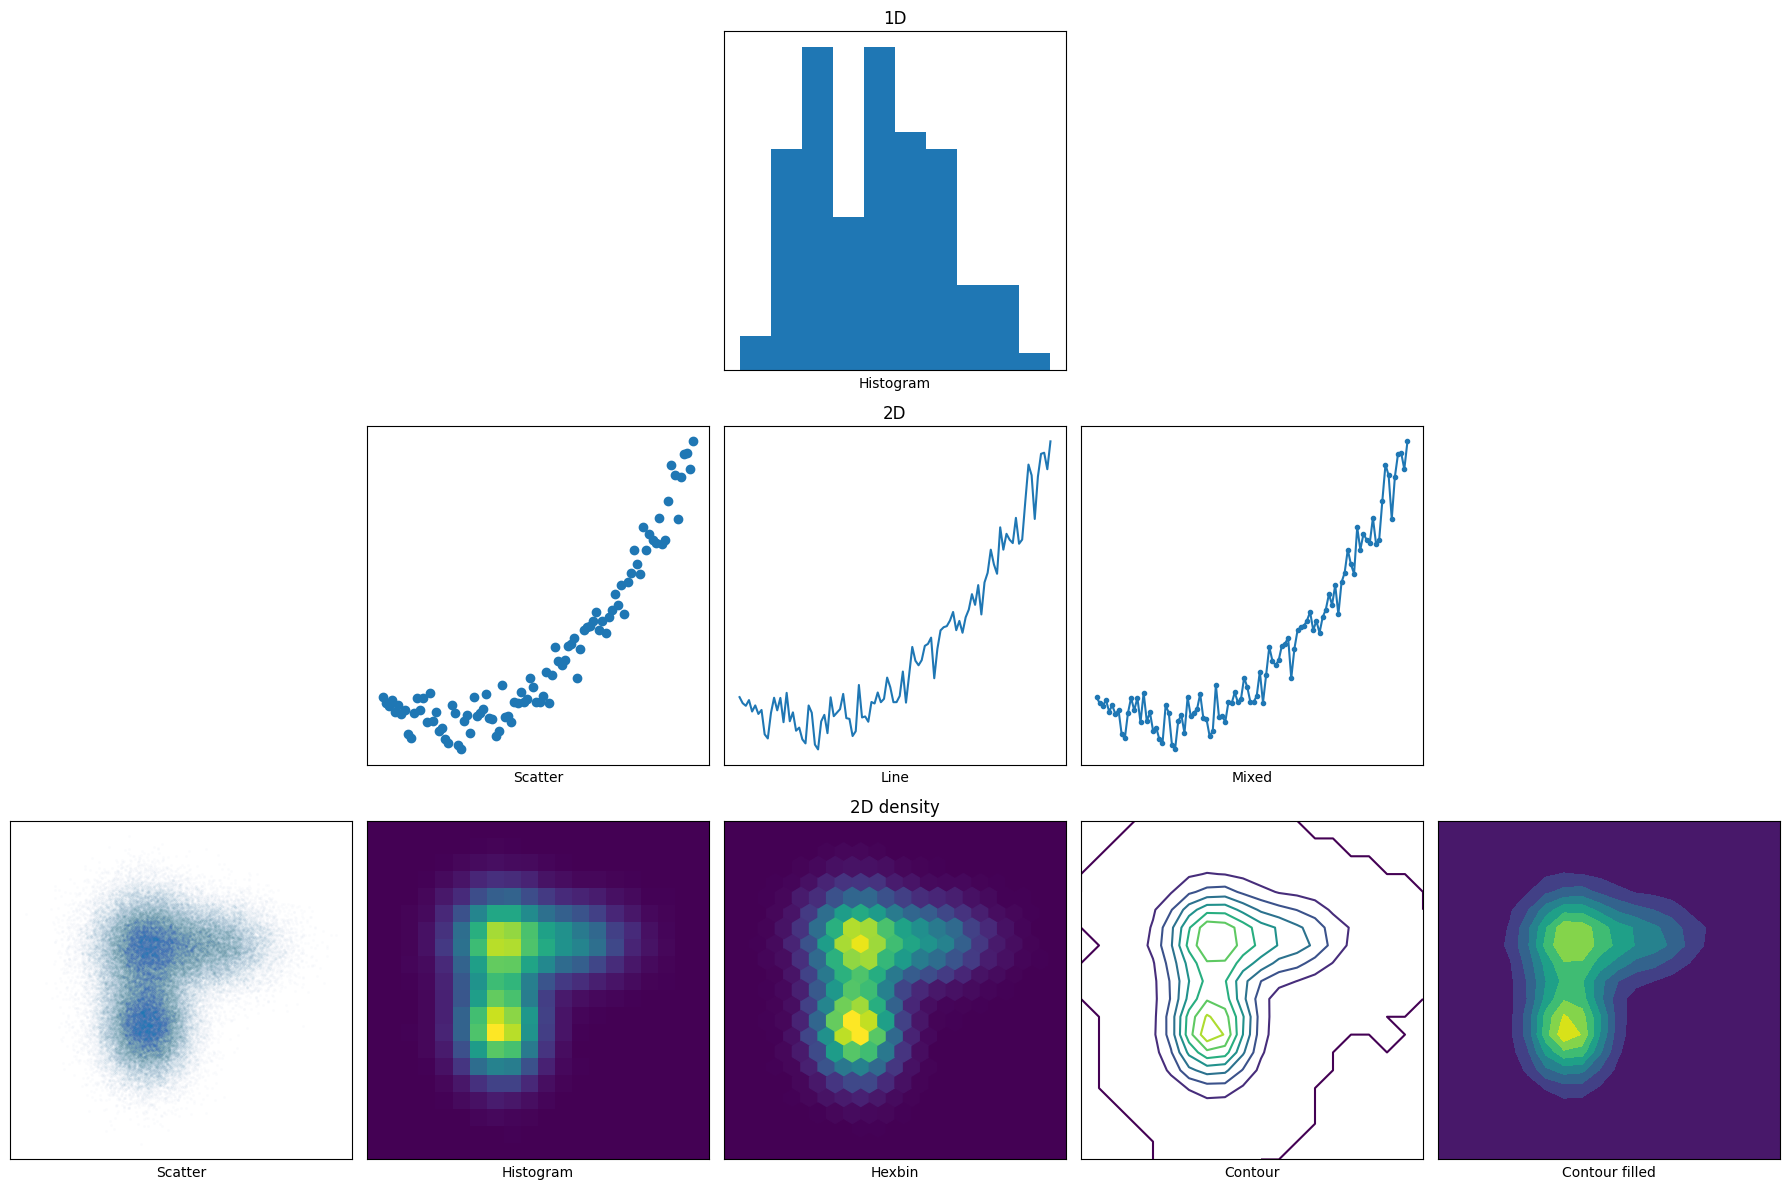

In [11]:
plots()

#### Customizing a plot
There are many ways of customizing a plot and you will have to find whatever works best for you. 

But making sure the plot looks good *is important*.

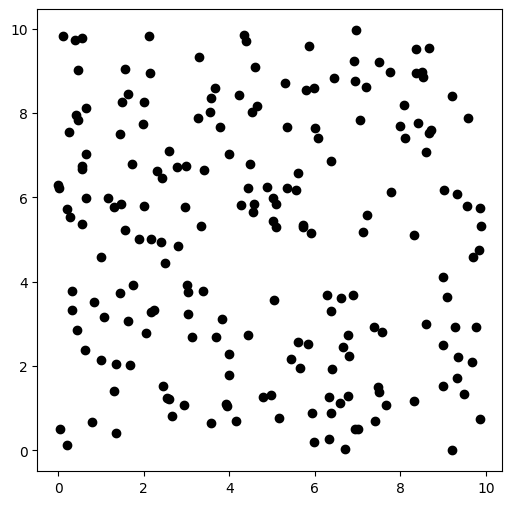

In [12]:
plt.figure(figsize=(6, 6))
x = rng.uniform(0, 10, size=200)
y = rng.uniform(0, 10, size=200)
plt.scatter(x, y, c="k")
plt.show()

Here is a simple scatter plot with almost no customization.

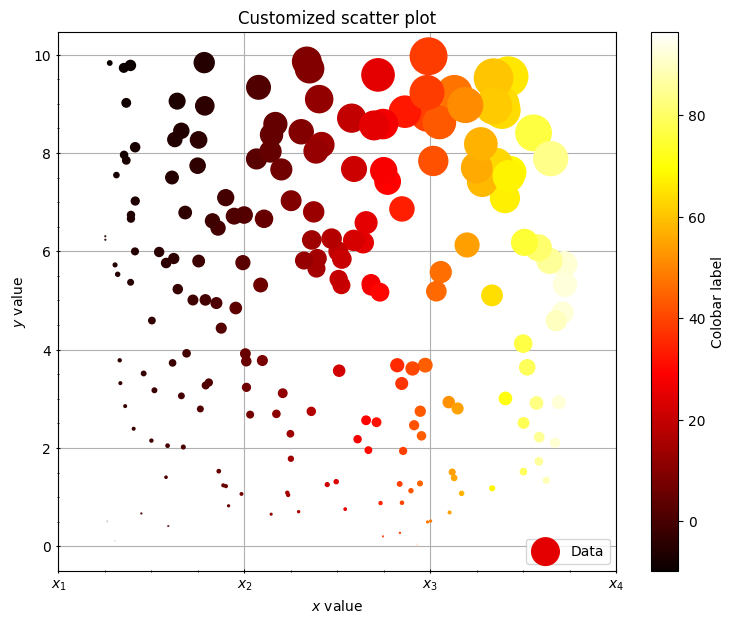

In [20]:
plt.figure(figsize=(9, 7))
plt.scatter(x, y, s=x * y**2, c=-y + x**2, cmap="hot", label="Data") #size and color depends on x and y
plt.xlabel("$x$ value")
plt.xticks(ticks=range(-1, 12, 4), labels=[f"$x_{i}$" for i in range(1, 5)])
plt.ylabel("$y$ value")
plt.minorticks_on()
plt.tick_params(which="both", direction="inout")
plt.title("Customized scatter plot")
plt.legend(fancybox=True, loc="lower right")
plt.colorbar(label="Colobar label")
plt.gca().set_axisbelow(True)
plt.grid()
plt.show()

The same basic type of plot can be customized in many different ways. Matplotlib gives us control over almost every part of the figure.

It isn't always easy to see what makes plots good. Let's talk about some bad ones.  
What's wrong with this one?

<center>
    <img src="https://lund-observatory-teaching.github.io/lundpython/imgs/bad1.png" width="1000" align="middle" style="margin: 0pt 0pt 0pt 0pt;"/>
</center>


- **Too many overlapping points** → difficult to see the density.
- **Repeated ticks** → unnecessary clutter.
- **Panels are not clearly identified** → the caption is needed.
- **Too crowded** → difficult to understand quickly.
- **Good:** shared scales, shared labels clear units.

What's wrong with this figure?
<center>
    <img src="https://lund-observatory-teaching.github.io/lundpython/imgs/bad2.png" width="1300" align="middle" style="margin: 0pt 0pt 0pt 0pt;"/>
</center>

- **Left:** too many/narrow bins → distribution is difficult to see.
- **Right:** too few/wide bins → too much detail is lost.
- **Main lesson:** bin choice changes how the data look, choose bins that show the structure without too much noise.

<center>
    <img src="https://lund-observatory-teaching.github.io/lundpython/imgs/bad3.png" width="900" align="middle" style="margin: 0pt 0pt 0pt 0pt;"/>
</center>

- **Too many lines** → difficult to follow.
- **Groups are distinguished only by colour** → less accessible for some readers or if black/white.
- **Line styles are not clearly explained** → need the caption.
- **Legend labels are unclear** → “08”, “09”, “10” need explanation.
- **Long caption** → too much information outside the figure.

<center>
    <img src="https://lund-observatory-teaching.github.io/lundpython/imgs/bad4.png" width="1000" align="middle" style="margin: 0pt 0pt 0pt 0pt;"/>
</center>

- **Too much information** → difficult to see the main result.
- **Strong grid** → distracts from the data.
- **Curves are not clearly explained** → no clear legend.
- **Colourbar is unclear** → no label or units.

<center>
    <img src="https://lund-observatory-teaching.github.io/lundpython/imgs/bad5.png" width="1300" align="middle" style="margin: 0pt 0pt 0pt 0pt;"/>
</center>

- **Large x-axis range** → important changes are compressed → consider a logarithmic x-axis.
- **Too much empty space** → not used effectively.
- **X-axis values are difficult to read** → large numbers could be formatted better → scientific notation.
- **Line connecting points** → may suggest a continuous measurement.

What makes this a good plot?
<center>
    <img src="https://s3.amazonaws.com/aasie/images/0004-637X/935/2/null/apjac7c74f4_hr.jpg" width="1000" align="middle" style="margin: 10pt 10pt 10pt 10pt;"/>
</center>

- **Clear title and labels** → easy to understand.
- **Separate plots** → each shows one quantity.
- **Same x-axis** → easy to compare over time.
- **Grey and black lines** → raw data and trend are easy to tell apart.
- **Clear legend** → explains the lines.
- **Black line stands out** → the main trend is easy to see.
- **Same style in both plots** → easy to compare.

### Choosing [colormaps](https://matplotlib.org/stable/tutorials/colors/colormaps.html)

Choosing the right colormap can make your data easier to understand and important features easier to see. A logarithmic scale can sometimes help reveal structures that are otherwise difficult to see.[Matplotlib's default colormap.](https://cran.r-project.org/web/packages/viridis/vignettes/intro-to-viridis.html)

<img src="https://lund-observatory-teaching.github.io/lundpython/imgs/colormaps.jpeg" width="1900">

### Vector and raster images

**Vector images** are made from shapes, lines, and points. They can be resized or zoomed in without losing quality.

**Raster images** are made from pixels. When zoomed in, the individual pixels become visible and the image can look blurry or pixelated.
<center>
    <img src="https://lund-observatory-teaching.github.io/lundpython/imgs/vector_or_raster.jpeg" width="1300">
</center>

For scientific plots, **vector formats are often the best choice** because they stay sharp when resized.

**Common formats**

- Vector: *PDF, SVG, EPS*
- Raster: *PNG, JPEG, GIF*

For plots with very many data points, vector files can become very large.

In this case, you can **rasterize the data** while keeping text and axes as vectors.

```python
plt.plot(x, y, rasterized=True)
plt.savefig('filename.pdf', format='pdf')
```

### How to make good plots in 10 rules

1. **Know the purpose** – what do you want to show?
2. **Make it readable** – check how it looks in the final PDF or presentation.
3. **Include a clear caption** – explain what the figure shows.
4. **Don't rely on default settings** – adjust them to your data.
5. **Use colour carefully** – it should help, not distract.
6. **Don't mislead the reader** – for example, connecting points can imply a continuous trend.
7. **Avoid overcrowding** – don't put too much information in one plot.
8. **Include units** where relevant.
9. **Use readable font sizes.**
10. **Choose the right type of plot** for the data and message.

# Now it's time to use the manual to solve the exercises. Good luck!